In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [12]:
from sklearn.linear_model import LassoCV
from sklearn.preprocessing import StandardScaler
import pandas as pd
import numpy as np

In [4]:
base_path = "/content/drive/MyDrive/GDA_Project/"

combined = pd.read_csv(base_path + "combined_expression.csv", index_col=0)
combined.index = combined.index.str.upper()
combined = combined.groupby(combined.index).mean()

deg_filtered = pd.read_csv(base_path + "DEG_filtered.csv")
deg_filtered["gene"] = deg_filtered["gene"].str.upper()

tf_list = pd.read_csv(base_path + "tf_list.csv", header=None)[0].tolist()
tf_list = [g.upper() for g in tf_list]

In [5]:
deg_genes = list(deg_filtered["gene"])
tf_genes = list(set(tf_list).intersection(deg_genes))

# Matrices
X = combined.loc[tf_genes].T   # (samples × TFs)
Y = combined.loc[deg_genes].T  # (samples × genes)

print("X:", X.shape)
print("Y:", Y.shape)

X: (590, 438)
Y: (590, 6098)


In [6]:
print("NaNs in X:", np.isnan(X.values).sum())
print("NaNs in Y:", np.isnan(Y.values).sum())

NaNs in X: 3
NaNs in Y: 125


In [7]:
X = X.fillna(X.mean(axis=1), axis=0)
Y = Y.fillna(Y.mean(axis=1), axis=0)

In [8]:
# Clean data
X = X.fillna(0)
Y = Y.fillna(0)

# Optional: remove constant genes
X = X.loc[:, X.std() > 0]

In [14]:
#Normalization
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
Y_values = Y.values   # add this line

Train LASSO for EACH GENE

In [1]:
!pip install cuml-cu12 --extra-index-url=https://pypi.nvidia.com

Looking in indexes: https://pypi.org/simple, https://pypi.nvidia.com
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.1/40.1 MB 44.3 MB/s eta 0:00:00
  Attempting uninstall: nvidia-cuda-nvcc-cu12
    Found existing installation: nvidia-cuda-nvcc-cu12 12.5.82
    Uninstalling nvidia-cuda-nvcc-cu12-12.5.82:
      Successfully uninstalled nvidia-cuda-nvcc-cu12-12.5.82


In [13]:
import cupy as cp
from cuml.linear_model import Ridge

In [15]:
# Convert to numpy
X_np = X_scaled
Y_np = Y_values

print("Final shapes:")
print("X:", X_np.shape)
print("Y:", Y_np.shape)

# Move to GPU
X_gpu = cp.asarray(X_np, dtype=cp.float32)
Y_gpu = cp.asarray(Y_np, dtype=cp.float32)

# Train ONE model for ALL genes
model = Ridge(alpha=1.0)

model.fit(X_gpu, Y_gpu)

# Get coefficients
coef_gpu = model.coef_   # (n_genes, n_TFs)
coef = cp.asnumpy(coef_gpu)

print("Coefficient matrix shape:", coef.shape)

Final shapes:
X: (590, 438)
Y: (590, 6098)
Coefficient matrix shape: (6098, 438)


In [16]:
edges = []

threshold = 0.01  # tune this

tf_names = X.columns
gene_names = Y.columns

for i, gene in enumerate(gene_names):
    for j, tf in enumerate(tf_names):
        weight = coef[i, j]
        if abs(weight) > threshold:
            edges.append([tf, gene, weight])

network_df = pd.DataFrame(edges, columns=["TF", "Target", "Weight"])

print("Total edges:", len(network_df))
network_df.head()

Total edges: 2169217


,TF,Target,Weight
0,ATOH8,15E1.2,0.063364
1,MEIS2,15E1.2,-0.063659
2,HOXB9,15E1.2,-0.053060
3,IRF9,15E1.2,0.034858
4,IRX4,15E1.2,0.038373


In [17]:
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np
import matplotlib.pyplot as plt

# Predictions (move back to CPU)
Y_pred_gpu = model.predict(X_gpu)
Y_pred = cp.asnumpy(Y_pred_gpu)

# True values
Y_true = Y_values

# ---- Metrics ----
r2 = r2_score(Y_true, Y_pred, multioutput='uniform_average')
mse = mean_squared_error(Y_true, Y_pred)

print("R2 Score:", r2)
print("MSE:", mse)

R2 Score: 0.9346606536692813
MSE: 0.06968219223790048


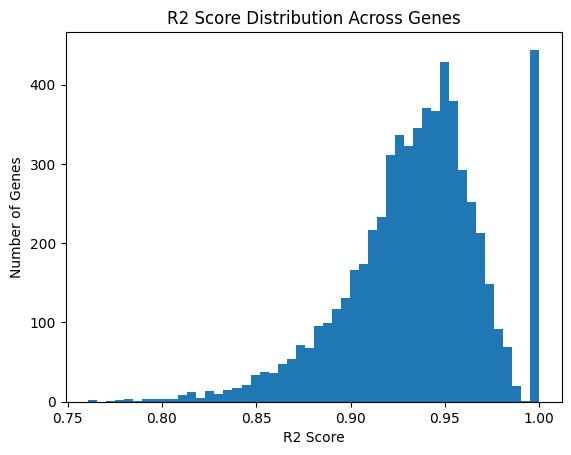

In [18]:
# Per gene R2
r2_per_gene = r2_score(Y_true, Y_pred, multioutput='raw_values')

plt.figure()
plt.hist(r2_per_gene, bins=50)
plt.title("R2 Score Distribution Across Genes")
plt.xlabel("R2 Score")
plt.ylabel("Number of Genes")
plt.show()

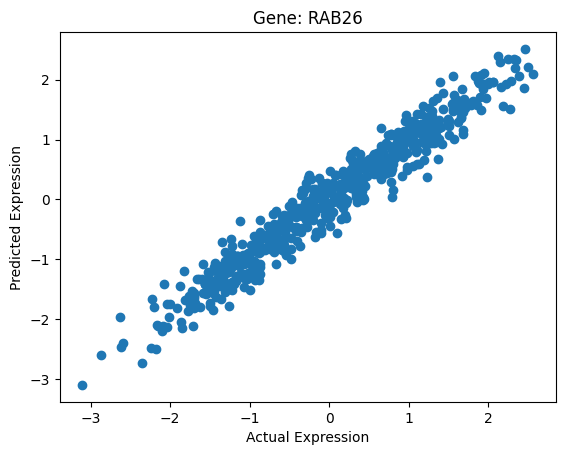

In [19]:
# Pick random gene
gene_idx = np.random.randint(0, Y_true.shape[1])

plt.figure()
plt.scatter(Y_true[:, gene_idx], Y_pred[:, gene_idx])
plt.xlabel("Actual Expression")
plt.ylabel("Predicted Expression")
plt.title(f"Gene: {gene_names[gene_idx]}")
plt.show()

In [20]:
import networkx as nx

G = nx.DiGraph()

# Add edges (limit for visualization)
top_edges = network_df.sort_values(by="Weight", key=abs, ascending=False).head(200)

for _, row in top_edges.iterrows():
    G.add_edge(row["TF"], row["Target"], weight=row["Weight"])

print("Nodes:", G.number_of_nodes())
print("Edges:", G.number_of_edges())

Nodes: 184
Edges: 200


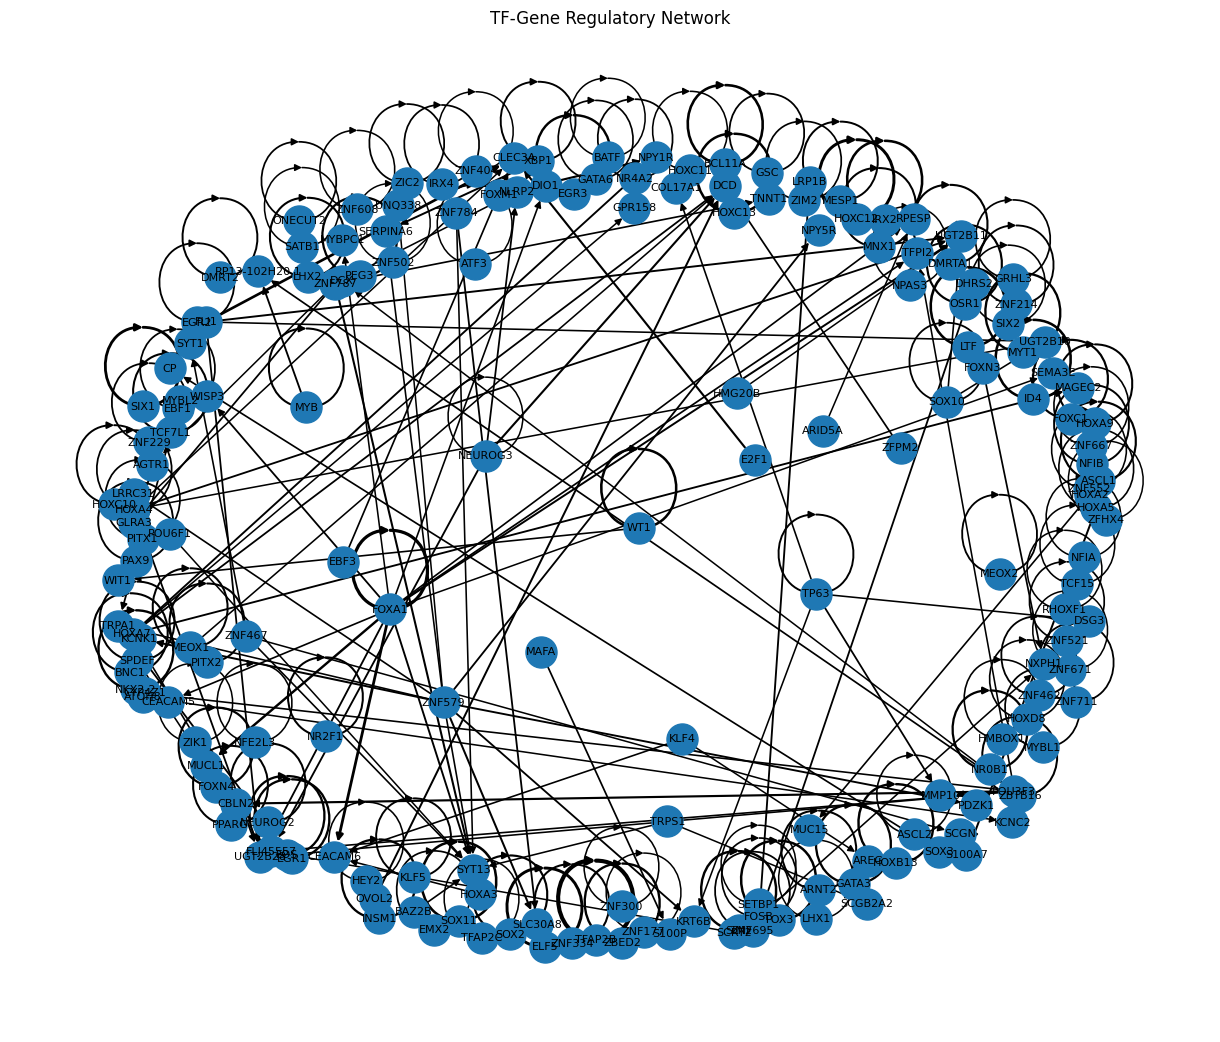

In [21]:
plt.figure(figsize=(12, 10))

pos = nx.spring_layout(G, k=0.5)

edges = G.edges(data=True)
weights = [abs(d['weight']) for (_, _, d) in edges]

nx.draw(
    G, pos,
    with_labels=True,
    node_size=500,
    font_size=8,
    width=weights
)

plt.title("TF-Gene Regulatory Network")
plt.show()

In [22]:
# Degree (importance)
degree_dict = dict(G.degree())

# Top TFs
top_nodes = sorted(degree_dict, key=degree_dict.get, reverse=True)[:10]

print("Top regulatory TFs:")
print(top_nodes)

Top regulatory TFs:
['FOXA1', 'ZNF579', 'POU3F3', 'SYT13', 'TP63', 'HOXA4', 'CLEC3A', 'NEUROG3', 'DCD', 'ZNF787']


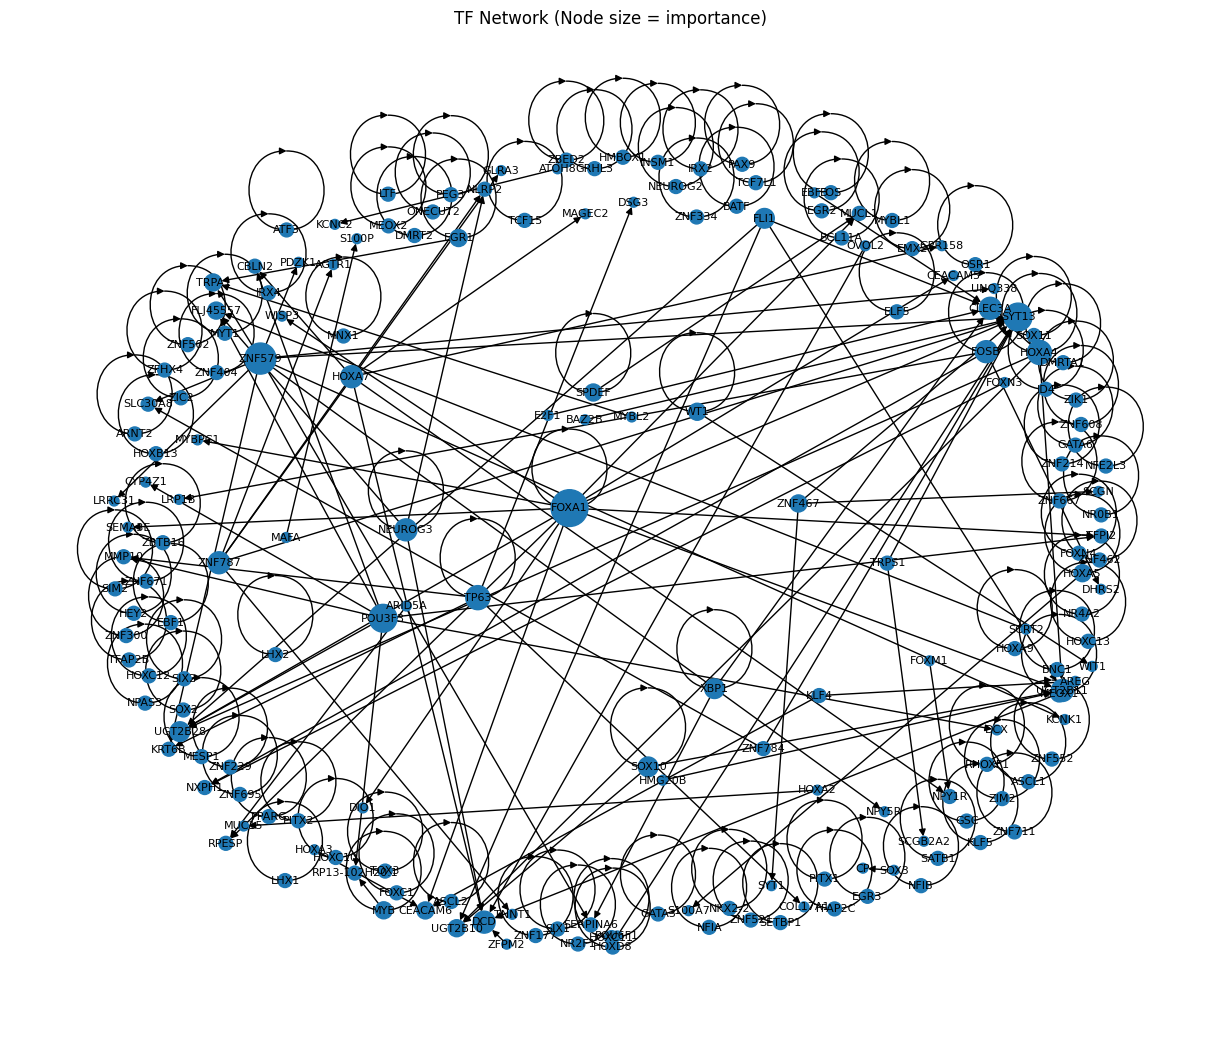

In [23]:
plt.figure(figsize=(12, 10))

pos = nx.spring_layout(G, k=0.5)

node_sizes = [degree_dict[n] * 50 for n in G.nodes()]

nx.draw(
    G, pos,
    with_labels=True,
    node_size=node_sizes,
    font_size=8
)

plt.title("TF Network (Node size = importance)")
plt.show()

In [24]:
network_df.to_csv("tf_gene_network.csv", index=False)

In [25]:
top_edges = network_df.nlargest(200, 'Weight')

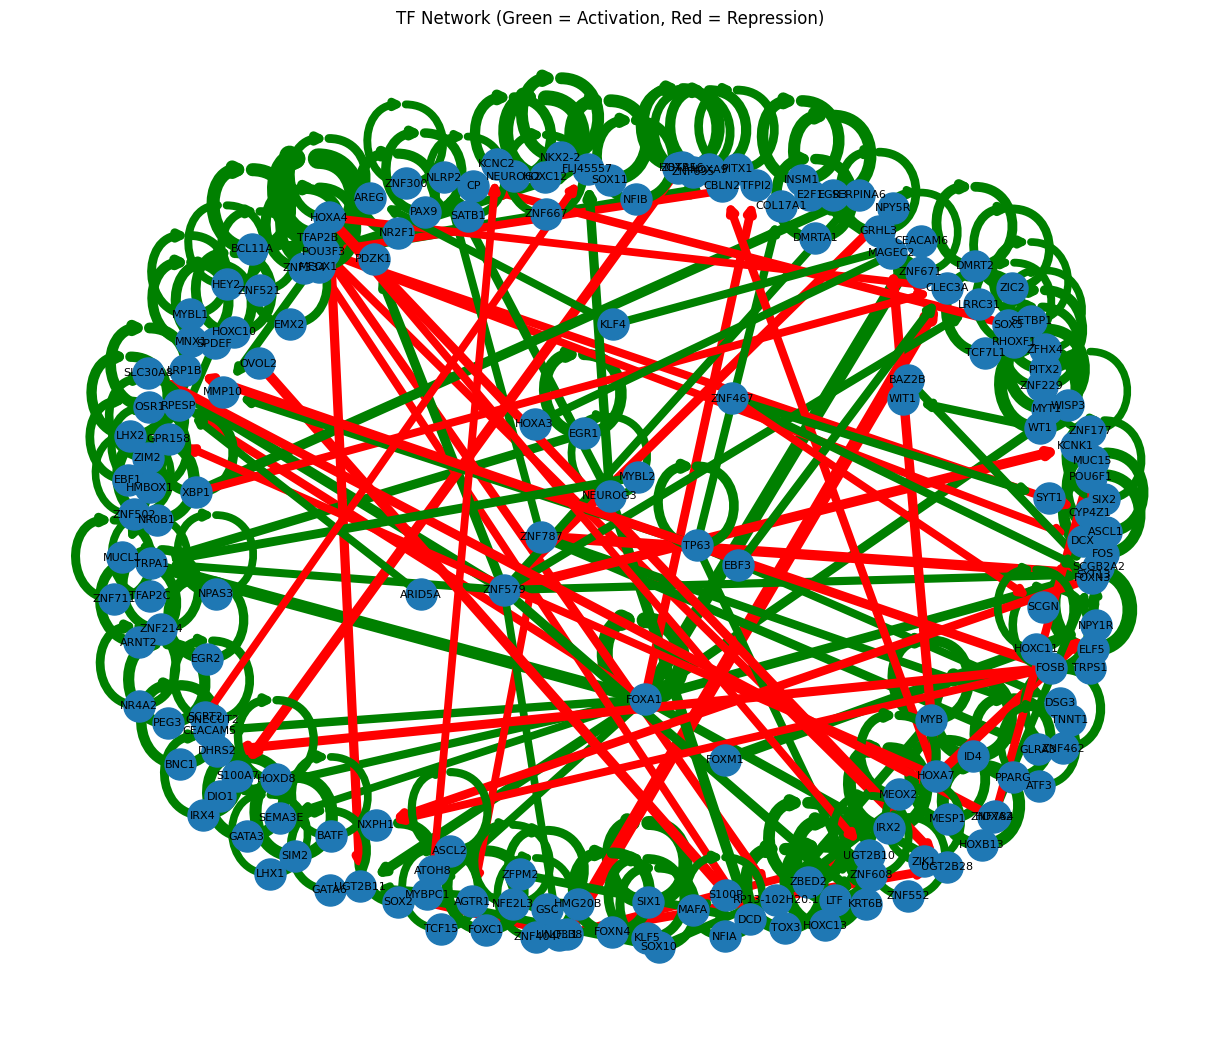

In [26]:
import networkx as nx
import matplotlib.pyplot as plt

G = nx.DiGraph()

top_edges = network_df.sort_values(by="Weight", key=abs, ascending=False).head(200)

for _, row in top_edges.iterrows():
    G.add_edge(row["TF"], row["Target"], weight=row["Weight"])

pos = nx.spring_layout(G, k=0.5)

# Edge colors
edge_colors = [
    "green" if d["weight"] > 0 else "red"
    for (_, _, d) in G.edges(data=True)
]

# Edge widths
edge_weights = [abs(d["weight"]) * 5 for (_, _, d) in G.edges(data=True)]

plt.figure(figsize=(12, 10))

nx.draw(
    G, pos,
    with_labels=True,
    node_size=500,
    font_size=8,
    edge_color=edge_colors,
    width=edge_weights
)

plt.title("TF Network (Green = Activation, Red = Repression)")
plt.show()

In [42]:
import plotly.graph_objects as go
import networkx as nx

# Reduce size
network_small = network_clean.nlargest(200, 'Weight')

G = nx.DiGraph()
for _, row in network_small.iterrows():
    G.add_edge(row["TF"], row["Target"], weight=row["Weight"])

# FAST layout
pos = nx.kamada_kawai_layout(G)   # or circular_layout for max speed

# Edges
edge_x = []
edge_y = []

for u, v in G.edges():
    x0, y0 = pos[u]
    x1, y1 = pos[v]
    edge_x.extend([x0, x1, None])
    edge_y.extend([y0, y1, None])

edge_trace = go.Scatter(
    x=edge_x, y=edge_y,
    line=dict(width=1),
    hoverinfo='none',
    mode='lines'
)

# Nodes (NO TEXT → faster)
node_x = []
node_y = []

for node in G.nodes():
    x, y = pos[node]
    node_x.append(x)
    node_y.append(y)

node_trace = go.Scatter(
    x=node_x, y=node_y,
    mode='markers',
    hoverinfo='text',
    marker=dict(size=8)
)

fig = go.Figure(
    data=[edge_trace, node_trace],
    layout=go.Layout(
        title="Fast Interactive TF Network",
        showlegend=False
    )
)

fig.show()

In [43]:
import plotly.graph_objects as go
import networkx as nx

# ================================
# STEP 1: Reduce graph size
# ================================
network_small = network_clean.nlargest(200, 'Weight')

G = nx.DiGraph()
for _, row in network_small.iterrows():
    G.add_edge(row["TF"], row["Target"], weight=row["Weight"])

# ================================
# STEP 2: Fast layout
# ================================
pos = nx.kamada_kawai_layout(G)   # faster than spring

# ================================
# STEP 3: Edges
# ================================
edge_x = []
edge_y = []

for u, v in G.edges():
    x0, y0 = pos[u]
    x1, y1 = pos[v]
    edge_x.extend([x0, x1, None])
    edge_y.extend([y0, y1, None])

edge_trace = go.Scatter(
    x=edge_x, y=edge_y,
    line=dict(width=1),
    hoverinfo='none',
    mode='lines'
)

# ================================
# STEP 4: Nodes
# ================================
node_x = []
node_y = []
node_text = []

for node in G.nodes():
    x, y = pos[node]
    node_x.append(x)
    node_y.append(y)
    node_text.append(node)   # full name on hover

# ================================
# STEP 5: Select nodes to label
# ================================
# Only label top TFs (important nodes)

degree_dict = dict(G.degree())
top_nodes = sorted(degree_dict, key=degree_dict.get, reverse=True)[:15]

label_x = []
label_y = []
label_text = []

for node in top_nodes:
    x, y = pos[node]
    label_x.append(x)
    label_y.append(y)
    label_text.append(node)

# ================================
# STEP 6: Plot
# ================================
node_trace = go.Scatter(
    x=node_x, y=node_y,
    mode='markers',
    hovertext=node_text,   # show name on hover
    hoverinfo='text',
    marker=dict(size=8)
)

label_trace = go.Scatter(
    x=label_x, y=label_y,
    mode='text',
    text=label_text,
    textposition="top center"
)

fig = go.Figure(
    data=[edge_trace, node_trace, label_trace],
    layout=go.Layout(
        title="TF-Gene Network (Labeled Key Nodes)",
        showlegend=False
    )
)

fig.show()

In [41]:
import plotly.graph_objects as go

pos = nx.spring_layout(G, k=0.5)

edge_x = []
edge_y = []
edge_colors = []

for edge in G.edges(data=True):
    x0, y0 = pos[edge[0]]
    x1, y1 = pos[edge[1]]

    edge_x.extend([x0, x1, None])
    edge_y.extend([y0, y1, None])

    edge_colors.append("green" if edge[2]['weight'] > 0 else "red")

edge_trace = go.Scatter(
    x=edge_x, y=edge_y,
    line=dict(width=1),
    hoverinfo='none',
    mode='lines'
)

node_x = []
node_y = []
text = []

for node in G.nodes():
    x, y = pos[node]
    node_x.append(x)
    node_y.append(y)
    text.append(node)

node_trace = go.Scatter(
    x=node_x, y=node_y,
    mode='markers+text',
    text=text,
    textposition="top center",
    hoverinfo='text',
    marker=dict(size=10)
)

fig = go.Figure(data=[edge_trace, node_trace],
                layout=go.Layout(
                    title="Interactive TF-Gene Network",
                    showlegend=False
                ))

fig.show()

KeyboardInterrupt: 

In [ ]:
import plotly.graph_objects as go
import networkx as nx

def plot_interactive_network(network_clean, max_edges=200, title="Interactive TF-Gene Network (Cleaned)"):
    """
    Plot interactive TF-Gene network using Plotly + NetworkX
    Limits edges for better readability and performance.
    """

    if network_clean.empty:
        print("No edges available for visualization.")
        return

    # Keep strongest edges only
    network_plot = network_clean.copy()
    network_plot["abs_weight"] = network_plot["Weight"].abs()
    network_plot = network_plot.sort_values("abs_weight", ascending=False).head(max_edges)
    network_plot = network_plot.drop(columns=["abs_weight"])

    print(f"Plotting top {len(network_plot)} edges")

    # Build directed graph
    G_new = nx.DiGraph()
    for _, row in network_plot.iterrows():
        G_new.add_edge(row["TF"], row["Target"], weight=row["Weight"])

    # Layout
    pos_new = nx.spring_layout(G_new, k=0.8, seed=42)

    # Edge coordinates
    edge_x_new = []
    edge_y_new = []

    for edge in G_new.edges(data=True):
        x0, y0 = pos_new[edge[0]]
        x1, y1 = pos_new[edge[1]]

        edge_x_new.extend([x0, x1, None])
        edge_y_new.extend([y0, y1, None])

    edge_trace_new = go.Scatter(
        x=edge_x_new,
        y=edge_y_new,
        line=dict(width=1, color='lightgray'),
        hoverinfo='none',
        mode='lines'
    )

    # Node coordinates
    node_x_new = []
    node_y_new = []
    text_new = []

    for node in G_new.nodes():
        x, y = pos_new[node]
        node_x_new.append(x)
        node_y_new.append(y)
        text_new.append(node)

    node_trace_new = go.Scatter(
        x=node_x_new,
        y=node_y_new,
        mode='markers+text',
        text=text_new,
        textposition="top center",
        hoverinfo='text',
        marker=dict(
            size=10,
            color='blue'
        )
    )

    fig_new = go.Figure(
        data=[edge_trace_new, node_trace_new],
        layout=go.Layout(
            title=title,
            showlegend=False,
            hovermode='closest',
            margin=dict(b=20, l=5, r=5, t=40),
            annotations=[
                dict(
                    text="TF-Gene regulatory network (Plotly + NetworkX)",
                    showarrow=False,
                    xref="paper",
                    yref="paper",
                    x=0.005,
                    y=-0.002
                )
            ],
            xaxis=dict(showgrid=False, zeroline=False, showticklabels=False),
            yaxis=dict(showgrid=False, zeroline=False, showticklabels=False)
        )
    )

    fig_new.show()

In [28]:
degree_dict = dict(G.out_degree())  # TF → targets

top_tfs = sorted(degree_dict.items(), key=lambda x: x[1], reverse=True)[:10]

print("Top Master Regulators:")
for tf, deg in top_tfs:
    print(f"{tf}: regulates {deg} genes")

Top Master Regulators:
FOXA1: regulates 13 genes
ZNF579: regulates 10 genes
POU3F3: regulates 8 genes
ZNF787: regulates 5 genes
TP63: regulates 5 genes
HOXA7: regulates 5 genes
HOXA4: regulates 5 genes
FLI1: regulates 4 genes
NEUROG3: regulates 4 genes
FOSB: regulates 4 genes


In [29]:
strong_edges = network_df.reindex(
    network_df["Weight"].abs().sort_values(ascending=False).index
).head(10)

print("Strongest TF-Gene interactions:")
print(strong_edges)

Strongest TF-Gene interactions:
             TF   Target    Weight
1956826  TFAP2B   TFAP2B  2.956082
788537    FOXA1    FOXA1  2.303394
954764   HOXC12   HOXC12  2.141136
662154     ELF5     ELF5  2.115676
1808202    SIX1     SIX1  2.016678
431972    FOXA1  CEACAM6  1.993443
476261     FLI1   CLEC3A -1.913337
180225   BCL11A   BCL11A  1.881070
1200964     LTF      LTF  1.855690
1016450    IRX2     IRX2  1.854695


In [30]:
activation = (network_df["Weight"] > 0).sum()
repression = (network_df["Weight"] < 0).sum()

print("Activation edges:", activation)
print("Repression edges:", repression)

Activation edges: 1092170
Repression edges: 1077047


In [31]:
tf_name = top_tfs[0][0]  # top TF

targets = network_df[network_df["TF"] == tf_name] \
            .sort_values(by="Weight", key=abs, ascending=False) \
            .head(10)

print(f"Top targets of {tf_name}:")
print(targets)

Top targets of FOXA1:
            TF   Target    Weight
788537   FOXA1    FOXA1  2.303394
431972   FOXA1  CEACAM6  1.993443
1311959  FOXA1    MUCL1  1.746312
2092021  FOXA1  UGT2B11  1.414011
1932793  FOXA1    SYT13  1.375059
2093286  FOXA1  UGT2B28  1.328137
2133422  FOXA1    WISP3  1.299295
1958216  FOXA1    TFPI2 -1.259282
1698892  FOXA1    RPESP -1.206583
431555   FOXA1  CEACAM5  1.200472


In [32]:
import networkx as nx

G = nx.DiGraph()

top_edges = network_df.sort_values(by="Weight", key=abs, ascending=False).head(300)

for _, row in top_edges.iterrows():
    G.add_edge(row["TF"], row["Target"], weight=row["Weight"])

In [33]:
tf_set = set(network_df["TF"])

node_colors = []
node_sizes = []

degree_dict = dict(G.degree())

for node in G.nodes():
    if node in tf_set:
        node_colors.append("blue")   # TF
    else:
        node_colors.append("orange") # Gene

    node_sizes.append(degree_dict[node] * 50 + 50)

In [34]:
edge_colors = []
edge_widths = []

for (_, _, d) in G.edges(data=True):
    if d["weight"] > 0:
        edge_colors.append("green")   # activation
    else:
        edge_colors.append("red")     # repression

    edge_widths.append(abs(d["weight"]) * 5)

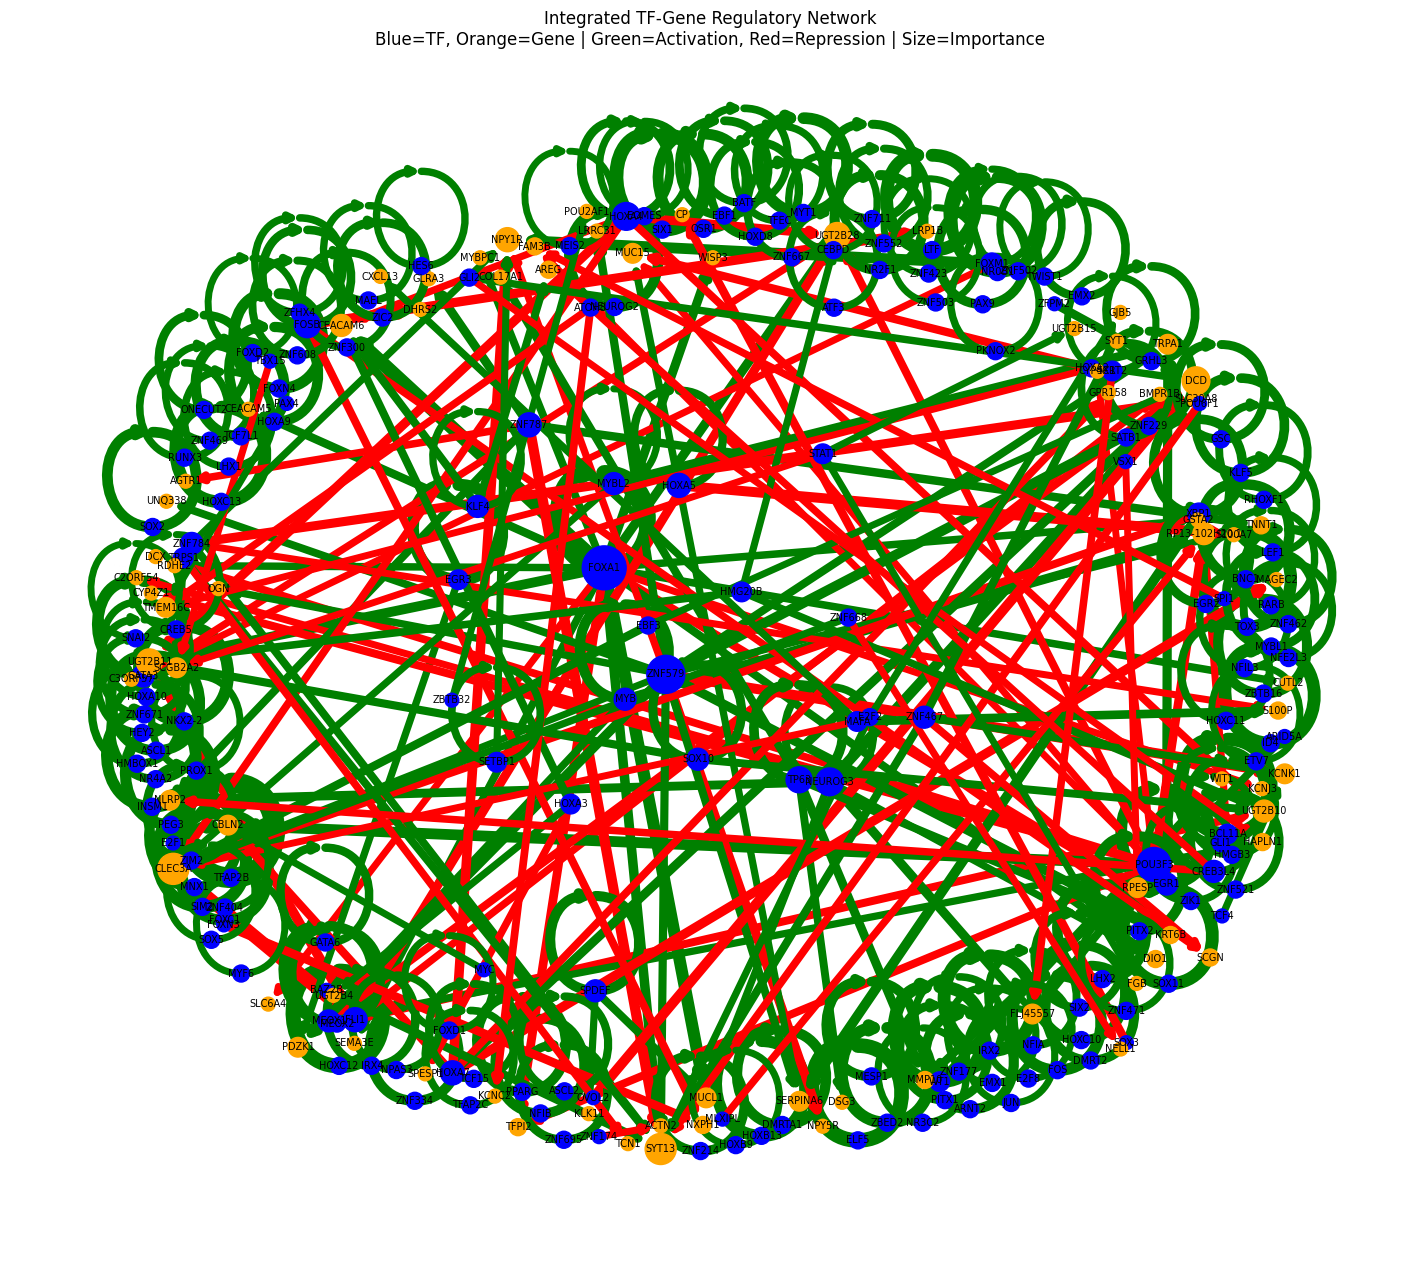

In [35]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 12))

pos = nx.spring_layout(G, k=0.5)

nx.draw(
    G, pos,
    with_labels=True,
    node_color=node_colors,
    node_size=node_sizes,
    edge_color=edge_colors,
    width=edge_widths,
    font_size=7
)

plt.title("Integrated TF-Gene Regulatory Network\n"
          "Blue=TF, Orange=Gene | Green=Activation, Red=Repression | Size=Importance")

plt.show()

In [37]:
# ======================================
# FAST STEP 1 + STEP 2 (Vectorized)
# ======================================

k = 3
threshold = 0.05

# Add absolute weight column (fast sorting)
network_df["abs_weight"] = network_df["Weight"].abs()

# Sort once (global sort)
network_sorted = network_df.sort_values(["Target", "abs_weight"], ascending=[True, False])

# Take top-k per gene (FAST GROUPBY)
network_clean = network_sorted.groupby("Target").head(k)

# Apply threshold filtering
network_clean = network_clean[network_clean["abs_weight"] > threshold]

# Drop helper column
network_clean = network_clean.drop(columns=["abs_weight"])

print("Final shape:", network_clean.shape)
network_clean.head()

Final shape: (17424, 3)


,TF,Target,Weight
7,EBF3,15E1.2,-0.262407
27,POU3F3,15E1.2,-0.242595
145,HIF3A,15E1.2,-0.171618
609,ZNF467,7A5,-0.460405
400,EGR2,7A5,-0.417459


In [36]:
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

# ================================
# STEP 1: Keep Top-k TFs per Gene
# ================================
# This reduces clutter by limiting connections per gene

k = 3  # number of TFs per gene

filtered_edges = []

for gene in network_df["Target"].unique():
    sub = network_df[network_df["Target"] == gene]

    # Sort by absolute weight (importance)
    sub_sorted = sub.reindex(sub["Weight"].abs().sort_values(ascending=False).index)

    top = sub_sorted.head(k)
    filtered_edges.append(top)

network_clean = pd.concat(filtered_edges)

print("After top-k filtering:", network_clean.shape)


# ======================================
# STEP 2: Remove Weak Edges (Threshold)
# ======================================
# Keeps only strong biological signals

threshold = 0.05

network_clean = network_clean[network_clean["Weight"].abs() > threshold]

print("After thresholding:", network_clean.shape)


# ======================================
# STEP 3: Focus on Top TFs (Reduce Nodes)
# ======================================
# Keeps only most influential TFs

top_tfs = network_clean["TF"].value_counts().head(10).index

network_focus = network_clean[network_clean["TF"].isin(top_tfs)]

print("After TF filtering:", network_focus.shape)


# ======================================
# STEP 4: Build Graph
# ======================================

G = nx.DiGraph()

for _, row in network_focus.iterrows():
    G.add_edge(row["TF"], row["Target"], weight=row["Weight"])


# ======================================
# STEP 5: Style Edges (Color + Width)
# ======================================
# Green = activation, Red = repression

edge_colors = []
edge_widths = []

for (_, _, d) in G.edges(data=True):
    if d["weight"] > 0:
        edge_colors.append("green")   # activation
    else:
        edge_colors.append("red")     # repression

    edge_widths.append(abs(d["weight"]) * 5)


# ======================================
# STEP 6: Style Nodes (Color + Size)
# ======================================
# TF = blue, Gene = orange
# Size = importance (degree)

tf_set = set(network_focus["TF"])

degree_dict = dict(G.degree())

node_colors = []
node_sizes = []

for node in G.nodes():
    if node in tf_set:
        node_colors.append("blue")    # TF
    else:
        node_colors.append("orange")  # Gene

    node_sizes.append(degree_dict[node] * 80 + 100)


# ======================================
# STEP 7: Use Better Layout + Clean Labels
# ======================================
# Kamada-Kawai gives better biological layouts

pos = nx.kamada_kawai_layout(G)

# Only label top TFs (avoid clutter)
labels = {node: node for node in top_tfs if node in G.nodes()}


# ======================================
# FINAL PLOT
# ======================================

plt.figure(figsize=(14, 12))

nx.draw(
    G, pos,
    with_labels=False,   # remove all labels first
    node_color=node_colors,
    node_size=node_sizes,
    edge_color=edge_colors,
    width=edge_widths,
    alpha=0.8
)

# Add only important labels
nx.draw_networkx_labels(G, pos, labels, font_size=10)

plt.title(
    "Clean TF-Gene Regulatory Network\n"
    "Blue=TF, Orange=Gene | Green=Activation, Red=Repression | Size=Importance"
)

plt.show()

KeyboardInterrupt: 

In [ ]:
import pandas as pd
import numpy as np

# ================================
# STEP 1: Keep Top-k TFs per Gene
# ================================
k = 3  # number of TFs to keep per gene

filtered_edges = []

for gene in network_df["Target"].unique():
    sub = network_df[network_df["Target"] == gene]

    # Sort by absolute weight (importance)
    sub_sorted = sub.reindex(sub["Weight"].abs().sort_values(ascending=False).index)

    # Keep top-k TFs for this gene
    top = sub_sorted.head(k)
    filtered_edges.append(top)

network_clean = pd.concat(filtered_edges)

print("After Step 1 (Top-k filtering):", network_clean.shape)


# ======================================
# STEP 2: Remove Weak Edges (Threshold)
# ======================================
threshold = 0.05  # adjust based on your data

network_clean = network_clean[network_clean["Weight"].abs() > threshold]

print("After Step 2 (Thresholding):", network_clean.shape)


# Preview
network_clean.head()

In [ ]:
edges = []

# Limit number of target genes for practical runtime
max_genes = min(500, len(deg_genes))
target_genes = deg_genes[:max_genes]

print(f"Running LASSO for {len(target_genes)} target genes...")

for i, gene in enumerate(target_genes):

    y = Y[gene].values

    # Skip constant / problematic genes
    if np.std(y) < 1e-6:
        continue

    try:
        # Faster Lasso model
        model = LassoCV(
            cv=3,              # reduced from 5
            n_jobs=-1,
            max_iter=5000,     # reduced from 20000
            tol=1e-2,          # looser tolerance = faster
            random_state=42
        )

        model.fit(X_scaled, y)

        coefs = model.coef_

        # Extract meaningful non-zero coefficients
        for j, coef in enumerate(coefs):
            if abs(coef) > 1e-4:
                tf = X.columns[j]
                if tf != gene:
                    edges.append([tf, gene, float(coef)])

    except Exception as e:
        print(f"Skipped {gene}: {e}")
        continue

    # Better progress log
    if (i + 1) % 50 == 0 or (i + 1) == len(target_genes):
        print(f"Processed {i + 1}/{len(target_genes)} genes")

Processed 0 genes
Processed 200 genes
Processed 400 genes
